# Прогнозирование цен на недвижимость с помощью линейной регрессии

**Работу выполнял:** Студент РГПУ им. А.И. Герцена, ИВТ, 2 курс, Елькин А.О.  

---

## Описание проекта

Этот проект направлен на использование линейной регрессии для прогнозирования цен на жильё на основе данных о его характеристиках, таких как площадь, количество комнат, возраст дома и другие параметры.

## Теоретическая основа: Линейная регрессия

### Что такое линейная регрессия?

Линейная регрессия — это статистический метод для моделирования взаимосвязи между:
- **Зависимой переменной** (target) - что мы хотим предсказать (в нашем случае - цена дома)
- **Независимыми переменными** (features) - признаки, влияющие на target

### Математическая формула

Модель линейной регрессии описывается уравнением:

$$ y = \beta_0 + \beta_1x_1 + \beta_2x_2 + ... + \beta_nx_n + \epsilon $$

где:
- $ y $ - целевая переменная (цена)
- $ \beta_0 $ - свободный член (intercept)
- $ \beta_1, \beta_2, ..., \beta_n $ - коэффициенты при признаках
- $ x_1, x_2, ..., x_n $ - признаки недвижимости
- $ \epsilon $ - ошибка модели

### Метрики оценки качества

Для оценки модели будем использовать:
- **MSE (Mean Squared Error)** - средняя квадратичная ошибка
- **RMSE (Root Mean Squared Error)** - корень из MSE
- **MAE (Mean Absolute Error)** - средняя абсолютная ошибка  
- **R² (R-squared)** - коэффициент детерминации

## Описание набора данных Boston Housing

### Общая информация

Boston Housing Dataset - классический набор данных, содержащий информацию о жилых районах Бостона. Данные собраны из переписи населения и содержат 506 наблюдений и 14 признаков.

### Переменные в наборе данных

| Признак | Описание | Единица измерения |
|---------|----------|-------------------|
| **CRIM** | Уровень преступности на душу населения | доля |
| **ZN** | Доля жилых участков под зданиями | % |
| **INDUS** | Доля не розничных бизнес-акров | % |
| **CHAS** | Граничит с рекой Чарльз (1 - да, 0 - нет) | бинарная |
| **NOX** | Концентрация оксидов азота | частиц на 10 млн |
| **RM** | Среднее количество комнат в жилище | комнаты |
| **AGE** | Доля домов, построенных до 1940 года | % |
| **DIS** | Взвешенное расстояние до центров занятости | мили |
| **RAD** | Индекс доступности к магистралям | индекс |
| **TAX** | Ставка налога на имущество | на \$10,000 |
| **PTRATIO** | Соотношение ученик-учитель в городе | соотношение |
| **B** | Показатель расового состава населения | индекс |
| **LSTAT** | Процент населения с низким статусом | % |
| **MEDV** | Медианная стоимость домов | **тысяч $** |

## Цели и задачи проекта

### Основная цель
Построить модель линейной регрессии для прогнозирования медианной стоимости домов в Бостоне на основе характеристик районов.

### Задачи

1. **Загрузка и исследование данных**
   - Изучить структуру набора данных
   - Провести разведочный анализ (EDA)
   - Выявить корреляции между признаками

2. **Подготовка данных**
   - Разделить данные на обучающую и тестовую выборки
   - Подготовить признаки для моделирования

3. **Построение модели**
   - Обучить модель линейной регрессии
   - Подобрать коэффициенты модели

4. **Оценка качества**
   - Протестировать модель на тестовых данных
   - Вычислить метрики качества
   - Проанализировать важность признаков

5. **Интерпретация результатов**
   - Сделать выводы о значимости факторов

In [ ]:
# Cell 1: Importing packages
using Pkg
Pkg.activate(".")

Pkg.add(["DataFrames", "RDatasets", "Plots", "Statistics", "GLM", "Random", "StatsPlots"])
using RDatasets, DataFrames, Plots, Statistics, GLM, Random, StatsPlots

println("Successfully installed packages!")

In [2]:
# Cell 2: Downloading Boston Housing dataset
# Boston Housing dataset is available with RDatasets
boston = dataset("MASS", "Boston")

println("Successfully downloaded data!")
println("Dataset size: ", size(boston))
println("\nFirst 5 lines:\n")
first(boston, 5)

Successfully downloaded data!
Dataset size: (506, 14)

First 5 lines:



Row,Crim,Zn,Indus,Chas,NOx,Rm,Age,Dis,Rad,Tax,PTRatio,Black,LStat,MedV
,Float64,Float64,Float64,Int64,Float64,Float64,Float64,Float64,Int64,Int64,Float64,Float64,Float64,Float64
1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.09,1,296,15.3,396.9,4.98,24.0
2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.9,9.14,21.6
3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.9,5.33,36.2


In [3]:
# Cell 3: Description of Boston dataset features
println("BOSTON HOUSING DATASET FEATURES DESCRIPTION:")
println("="^50)
features_description = """
CRIM - per capita crime rate by town
ZN - proportion of residential land zoned for lots over 25,000 sq.ft.
INDUS - proportion of non-retail business acres per town.
CHAS - Charles River dummy variable (1 if tract bounds river; 0 otherwise)
NOX - nitric oxides concentration (parts per 10 million)
RM - average number of rooms per dwelling
AGE - proportion of owner-occupied units built prior to 1940
DIS - weighted distances to five Boston employment centres
RAD - index of accessibility to radial highways
TAX - full-value property-tax rate per USD 10,000
PTRATIO - pupil-teacher ratio by town
B - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
LSTAT - % lower status of the population
MEDV - Median value of owner-occupied homes in 1,000 USD (FOCUS VALUE)
"""

println(features_description)
println("\nData structure:")
println(names(boston))

BOSTON HOUSING DATASET FEATURES DESCRIPTION:
CRIM - per capita crime rate by town
ZN - proportion of residential land zoned for lots over 25,000 sq.ft.
INDUS - proportion of non-retail business acres per town.
CHAS - Charles River dummy variable (1 if tract bounds river; 0 otherwise)
NOX - nitric oxides concentration (parts per 10 million)
RM - average number of rooms per dwelling
AGE - proportion of owner-occupied units built prior to 1940
DIS - weighted distances to five Boston employment centres
RAD - index of accessibility to radial highways
TAX - full-value property-tax rate per USD 10,000
PTRATIO - pupil-teacher ratio by town
B - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
LSTAT - % lower status of the population
MEDV - Median value of owner-occupied homes in 1,000 USD (FOCUS VALUE)


Data structure:
["Crim", "Zn", "Indus", "Chas", "NOx", "Rm", "Age", "Dis", "Rad", "Tax", "PTRatio", "Black", "LStat", "MedV"]


## Разведочный анализ данных (EDA)

Перед построением модели проведем визуальный анализ данных для понимания:
- Распределения целевой переменной (цен)
- Взаимосвязей между признаками и ценой
- Наличия выбросов и аномалий

### Ожидаемые взаимосвязи

На основе доменных знаний ожидаем, что:
- **Положительно влияют**: количество комнат (RM), статус района
- **Отрицательно влияют**: уровень преступности (CRIM), загрязнение (NOX)
- **Требуют проверки**: возраст домов (AGE), налоги (TAX)

BASIC STATISTICS:


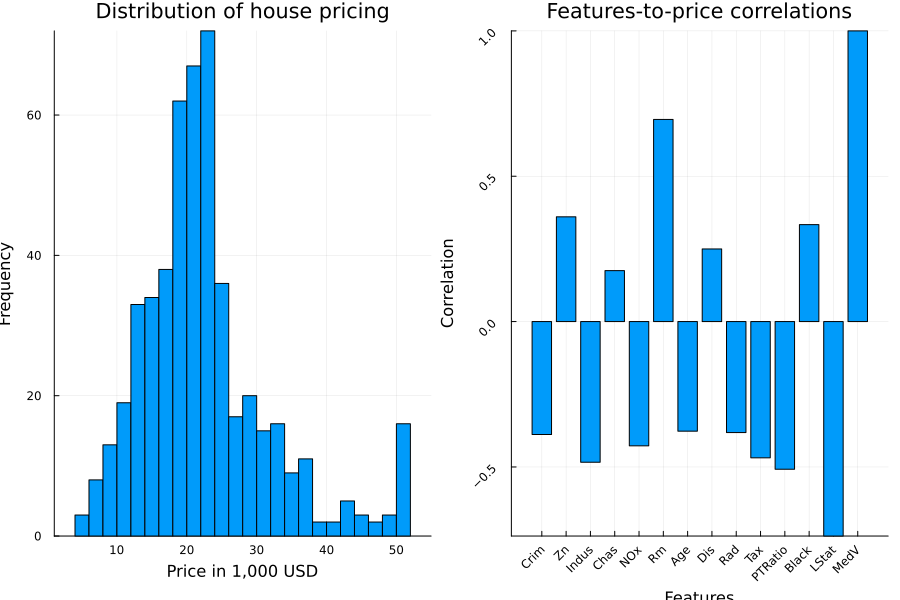

In [4]:
# Cell 4: Exploratory Data Analysis (EDA)
println("BASIC STATISTICS:")
describe(boston)

# Histogram of focus value (MedV - house pricing)
p1 = histogram(boston.MedV, title="Distribution of house pricing", 
               xlabel="Price in 1,000 USD", ylabel="Frequency", legend=false)

# Features-to-focus value correlations
correlations = [cor(boston[!, col], boston.MedV) for col in names(boston) if col != :MedV]
feature_names = [col for col in names(boston) if col != :MedV]

p2 = bar(feature_names, correlations, title="Features-to-price correlations",
         xlabel="Features", ylabel="Correlation", legend=false, rotation=45)

plot(p1, p2, layout=(1,2), size=(900,600))

TOP-4 features in price correlation:
1. LStat: -0.738
2. Rm: 0.695
3. PTRatio: -0.508
4. Indus: -0.484


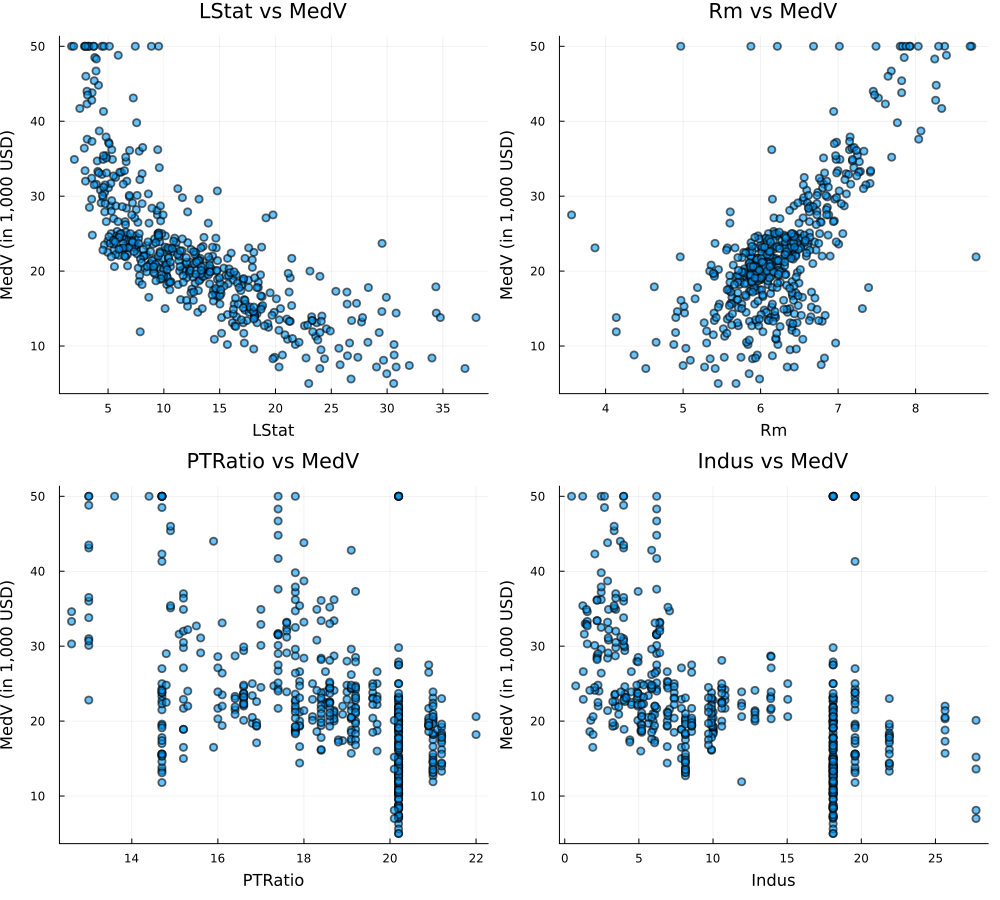

In [5]:
# Cell 5: Important interactions visualization
feature_names_without_target = [name for name in feature_names if name != "MedV"]
correlations_without_target = [cor(boston[!, col], boston.MedV) for col in feature_names_without_target]

sorted_corr = sort([(feature_names_without_target[i], correlations_without_target[i]) for i in 1:length(correlations_without_target)], 
                   by=x->abs(x[2]), rev=true)

top_features = [x[1] for x in sorted_corr[1:4]]
println("TOP-4 features in price correlation:")
for (i, (feature, corr)) in enumerate(sorted_corr[1:4])
    println("$i. $feature: $(round(corr, digits=3))")
end

# TOP-features visualization
p1 = scatter(boston[!, top_features[1]], boston.MedV,
            title="$(top_features[1]) vs MedV", 
            xlabel=top_features[1], ylabel="MedV (in 1,000 USD)",
            alpha=0.6, legend=false)

p2 = scatter(boston[!, top_features[2]], boston.MedV,
            title="$(top_features[2]) vs MedV", 
            xlabel=top_features[2], ylabel="MedV (in 1,000 USD)",
            alpha=0.6, legend=false)

p3 = scatter(boston[!, top_features[3]], boston.MedV,
            title="$(top_features[3]) vs MedV", 
            xlabel=top_features[3], ylabel="MedV (in 1,000 USD)",
            alpha=0.6, legend=false)

p4 = scatter(boston[!, top_features[4]], boston.MedV,
            title="$(top_features[4]) vs MedV", 
            xlabel=top_features[4], ylabel="MedV (in 1,000 USD)",
            alpha=0.6, legend=false)

plot(p1, p2, p3, p4, layout=(2,2), size=(1000,900))

## Построение модели линейной регрессии

### Подготовка данных к моделированию

Перед обучением модели необходимо:
- Разделить данные на обучающую (80%) и тестовую (20%) выборки
- Это позволит оценить способность модели к обобщению на новых данных

### Процесс обучения

Модель будет обучена с использованием метода наименьших квадратов (OLS), который минимизирует сумму квадратов ошибок между предсказанными и реальными значениями.

In [6]:
# Cell 6: Preparing data for the model
# Focus value
y = boston.MedV

# Features (minus Focus value)
X = boston[:, 1:end-1]

println("Features size: ", size(X))
println("Focus value size: ", size(y))

# Dividing into learning and testing samples (80/20)
Random.seed!(42)
n = nrow(boston)
train_indices = randperm(n)[1:Int(floor(0.8 * n))]
test_indices = setdiff(1:n, train_indices)

X_train = X[train_indices, :]
X_test = X[test_indices, :]
y_train = y[train_indices]
y_test = y[test_indices]

println("\nData division:")
println("Learning sample: ", size(X_train))
println("Testing sample: ", size(X_test))

Features size: (506, 13)
Focus value size: (506,)

Data division:
Learning sample: (404, 13)
Testing sample: (102, 13)


In [7]:
# Cell 7: Building linear regression model
println("TEACHING A LINEAR REGRESSION MODEL")
println("="^40)

# DataFrame for teaching
train_data = copy(X_train)
train_data.MedV = y_train

# Building linear regression model
# Using all features
linear_model = lm(@formula(MedV ~ Crim + Zn + Indus + Chas + NOx + Rm + Age + Dis + Rad + Tax + PTRatio + Black + LStat), train_data)

println("Model taught successfully!")
println("Model coefficients:")
coef_df = DataFrame(
    Feature = ["Intercept"; names(X)],
    Coefficient = round.(coef(linear_model), digits=3)
)
coef_df

global MODEL = linear_model

TEACHING A LINEAR REGRESSION MODEL
Model taught successfully!
Model coefficients:


StatsModels.TableRegressionModel{LinearModel{GLM.LmResp{Vector{Float64}}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}, Matrix{Float64}}

MedV ~ 1 + Crim + Zn + Indus + Chas + NOx + Rm + Age + Dis + Rad + Tax + PTRatio + Black + LStat

Coefficients:
─────────────────────────────────────────────────────────────────────────────────
                    Coef.  Std. Error      t  Pr(>|t|)     Lower 95%    Upper 95%
─────────────────────────────────────────────────────────────────────────────────
(Intercept)   37.9478      5.55653      6.83    <1e-10   27.0233      48.8724
Crim          -0.120428    0.0388579   -3.10    0.0021   -0.196825    -0.0440308
Zn             0.0481501   0.014427     3.34    0.0009    0.0197857    0.0765146
Indus          0.0312644   0.0656943    0.48    0.6344   -0.0978948    0.160424
Chas           0.624328    1.0213       0.61    0.5414   -1.38361      2.63227
NOx          -17.4258      4.40002     -3.96    <1

## Оценка качества модели

### Метрики для оценки

После обучения модели вычислим следующие метрики:

- **MSE (Mean Squared Error)**: 
  $$ MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2 $$
  - Средний квадрат разности между реальными и предсказанными значениями
  - Чем меньше, тем лучше

- **RMSE (Root Mean Squared Error)**:
  $$ RMSE = \sqrt{MSE} $$
  - Интерпретируемая в единицах целевой переменной
  - Показывает среднюю ошибку в тысячах долларов

- **R² (R-squared)**:
  $$ R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2} $$
  - Доля дисперсии, объясненная моделью
  - От 0 до 1 (чем ближе к 1, тем лучше)

In [8]:
# Cell 8: Predicting and model evaluation
# Based on testing sample
linear_model = MODEL

y_pred = predict(linear_model, X_test)

# Model evaluation function
function evaluate_model(y_true, y_pred, model_name="")
    mse = mean((y_true .- y_pred).^2)
    rmse = sqrt(mse)
    mae = mean(abs.(y_true .- y_pred))
    r2 = 1 - sum((y_true .- y_pred).^2) / sum((y_true .- mean(y_true)).^2)
    
    println("=== QUALITY METRICS: $model_name ===")
    println("Mean square root error (MSE): ", round(mse, digits=3))
    println("Square root of MSE (RMSE): ", round(rmse, digits=3))
    println("Mean absolute error (MAE): ", round(mae, digits=3))
    println("Coefficient of determination (R²): ", round(r2, digits=4))
    println("Variance explained: ", round(r2 * 100, digits=2), "%")
    
    return (mse=mse, rmse=rmse, mae=mae, r2=r2)
end

# Model evaluation
results = evaluate_model(y_test, y_pred, "Boston Housing Linear Regression")

=== QUALITY METRICS: Boston Housing Linear Regression ===
Mean square root error (MSE): 28.735
Square root of MSE (RMSE): 5.36
Mean absolute error (MAE): 3.68
Coefficient of determination (R²): 0.7024
Variance explained: 70.24%


(mse = 28.734506723385742, rmse = 5.360457697192073, mae = 3.679634329181543, r2 = 0.7024296235115235)

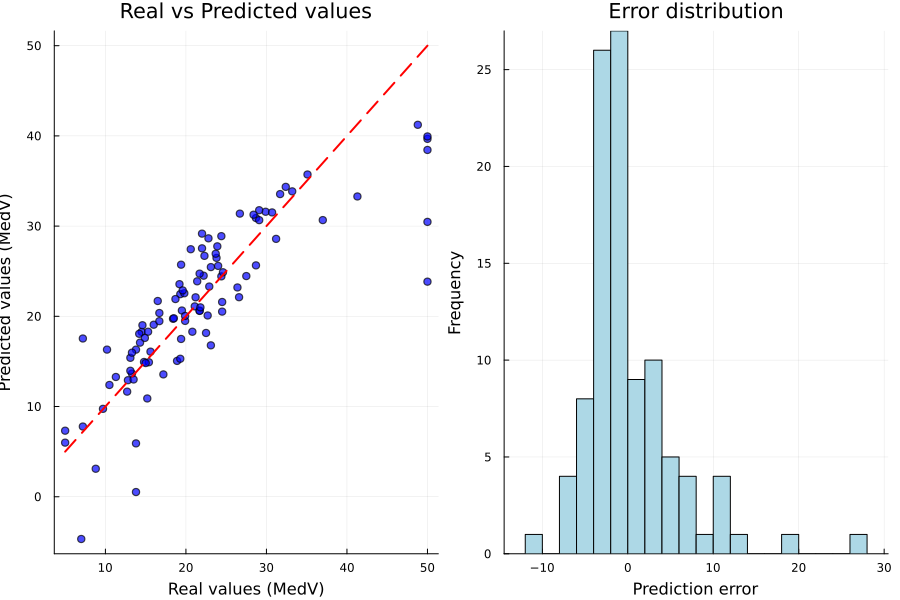

In [9]:
# Cell 9: Prediction results visualization
# Comparing real and predicted values
p1 = scatter(y_test, y_pred, alpha=0.7, color=:blue,
            xlabel="Real values (MedV)", 
            ylabel="Predicted values (MedV)",
            title="Real vs Predicted values",
            legend=false)

# Line of ideal predictions (y = x)
min_val, max_val = extrema(y_test)
plot!([min_val, max_val], [min_val, max_val], 
      linewidth=2, linecolor=:red, linestyle=:dash, label="Ideal line")

# Errors histogram
errors = y_test - y_pred
p2 = histogram(errors, bins=20, color=:lightblue,
              xlabel="Prediction error", 
              ylabel="Frequency",
              title="Error distribution",
              legend=false)

plot(p1, p2, layout=(1,2), size=(900,600))

FEATURE IMPORTANCY (by absolute coefficients):
1. NOx: -17.426 (↓ lowers price)
2. Rm: 3.718 (↑ raises price)
3. Dis: -1.44 (↓ lowers price)
4. PTRatio: -0.959 (↓ lowers price)
5. Chas: 0.624 (↑ raises price)


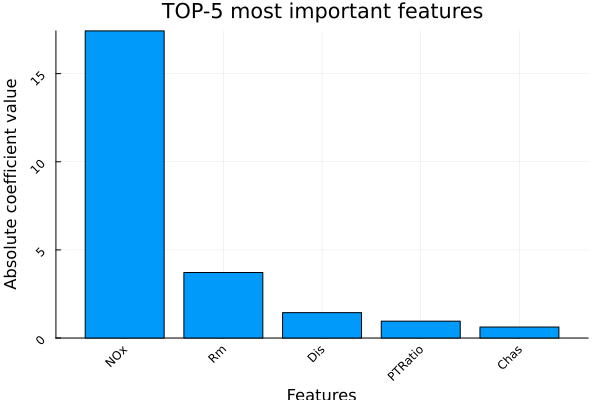

In [10]:
# Cell 10: Feature importancy analysis
# Model coefficients analysis
coefficients = coef(linear_model)
feature_names_with_intercept = ["Intercept"; names(X)]

# DataFrame with coefficients
importance_df = DataFrame(
    Feature = feature_names_with_intercept,
    Coefficient = coefficients,
    Abs_Coef = abs.(coefficients)
)

# Sorting by absolute coefficient value (except intercept)
sorted_importance = sort(importance_df[2:end, :], :Abs_Coef, rev=true)

println("FEATURE IMPORTANCY (by absolute coefficients):")
println("="^55)

for i in 1:min(5, nrow(sorted_importance))
    row = sorted_importance[i, :]
    effect = row.Coefficient > 0 ? "↑ raises" : "↓ lowers"
    println("$i. $(row.Feature): $(round(row.Coefficient, digits=3)) ($effect price)")
end

# TOP-5 features visualization
top_5_features = sorted_importance[1:5, :]
bar(top_5_features.Feature, top_5_features.Abs_Coef,
    title="TOP-5 most important features",
    xlabel="Features", ylabel="Absolute coefficient value",
    legend=false, rotation=45)

## Интерпретация результатов модели

### Анализ коэффициентов

Коэффициенты линейной регрессии показывают:
- **Направление влияния**: положительный коэффициент → увеличение цены
- **Силу влияния**: абсолютное значение коэффициента → важность признака
- **Статистическую значимость**: надежность выявленной зависимости

### Практическая значимость

Результаты могут быть использованы для:
- Оценки стоимости недвижимости
- Понимания факторов, влияющих на цены
- Принятия решений в сфере недвижимости

In [11]:
# Cell 11: Results interpretation and conclusion
println("MODEL RESULTS INTERPRETATION")
println("="^50)

coefficients = coef(linear_model)
feature_names_with_intercept = ["Intercept"; names(X)]

coef_analysis = DataFrame(
    Feature = feature_names_with_intercept,
    Coef = coefficients,
    Abs_Importance = abs.(coefficients)
)

sorted_coef = sort(coef_analysis[2:end, :], :Abs_Importance, rev=true)

println("TOP-5 MOST INFLUECIAL MODEL FEATURES:")
println("="^45)

for i in 1:min(5, nrow(sorted_coef))
    row = sorted_coef[i, :]
    effect = row.Coef > 0 ? "↑ RAISES" : "↓ LOWERS"
    change = abs(round(row.Coef, digits=1))
    
    if row.Feature == "Rm"
        println("$i. ROOMS (Rm): $effect price for $change in 1,000 USD per room")
    elseif row.Feature == "LStat"
        println("$i. LOW STATUS (LStat): $effect price for $change in 1,000 USD per 1%")
    elseif row.Feature == "PtRatio"
        println("$i. SCHOOLS (PtRatio): $effect price for $change in 1,000 USD per each unit")
    elseif row.Feature == "Nox"
        println("$i. POLLUTION (Nox): $effect price for $change in 1,000 USD per concentration")
    elseif row.Feature == "Indus"
        println("$i. INDUSTRIAL FACILITIES (Indus): $effect price for $change in 1,000 USD per % of territory")
    else
        println("$i. $(row.Feature): $effect price for $change in 1,000 USD")
    end
end

println("\n" * "="^50)
println("COMPARING TO CORRELATION ANALYSIS:")
println("="^50)

top_corr_features = [x[1] for x in sorted_corr[1:5]]
top_model_features = sorted_coef.Feature[1:5]

println("TOP in correlation: ", join(top_corr_features, ", "))
println("TOP in model: ", join(top_model_features, ", "))

common_features = intersect(top_corr_features, top_model_features)
if length(common_features) > 0
    println("MATCH: ", join(common_features, ", "), " - reliable predictors")
end

println("\n" * "="^50)
println("PRACTICAL INTERPRETATION:")
println("="^50)

significant_features = sorted_coef.Feature[1:7] 

for feature in significant_features
    coef_val = coef_analysis[coef_analysis.Feature .== feature, :Coef][1]
    
    if feature == "Rm"
        println("ROOMS: Each extra room adds ~$(round(coef_val*1000, digits=0))USD to house pricing")
    elseif feature == "LStat"
        println("SOCIAL STATUS: Increase in 1% in number of poor residents lowers the price for ~$(round(abs(coef_val)*1000, digits=0))USD")
    elseif feature == "Nox"
        println("ECOLOGY: Air pollution lowers house pricing")
    elseif feature == "PtRatio"
        println("EDUCATION: Low teacher-pupil ratio negatively impacts prices")
    elseif feature == "Indus"
        println("INDUSTRIAL FACILITIES: Proximity of industrial sites lowers house pricing")
    elseif feature == "Tax"
        println("TAXES: High real-estate taxes make area less attractive")
    elseif feature == "Crim"
        println("CRIME RATE: Crime rate seriously affects house pricing")
    end
end

println("\n" * "="^50)
println("OVERALL CONCLUSION:")
println("="^50)

println("Model explains $(round(results.r2 * 100, digits=1))% of price dispersion (R² = $(round(results.r2, digits=3)))")
println("Average prediction error: ±$(round(results.rmse, digits=1)) in 1,000 USD (RMSE)")
println("Model precision: MAE = $(round(results.mae, digits=1)) in 1,000 USD")

println("\nKEY FACTORS OF BOSTON REAL ESTATE MARKET:")
println("SOCIO-ECONOMICAL: LStat (status), PtRatio (education)")
println("PHYSICAL FEATURES: Rm (rooms), Age (building age)")  
println("ECOLOGY AND INFRASTRUCTURE: Nox (pollution), Indus (industrial facilities)")
println("FINANCIAL: Tax (taxes), Crim (crime rate)")

MODEL RESULTS INTERPRETATION
TOP-5 MOST INFLUECIAL MODEL FEATURES:
1. NOx: ↓ LOWERS price for 17.4 in 1,000 USD
2. ROOMS (Rm): ↑ RAISES price for 3.7 in 1,000 USD per room
3. Dis: ↓ LOWERS price for 1.4 in 1,000 USD
4. PTRatio: ↓ LOWERS price for 1.0 in 1,000 USD
5. Chas: ↑ RAISES price for 0.6 in 1,000 USD

COMPARING TO CORRELATION ANALYSIS:
TOP in correlation: LStat, Rm, PTRatio, Indus, Tax
TOP in model: NOx, Rm, Dis, PTRatio, Chas
MATCH: Rm, PTRatio - reliable predictors

PRACTICAL INTERPRETATION:
ROOMS: Each extra room adds ~3718.0USD to house pricing
SOCIAL STATUS: Increase in 1% in number of poor residents lowers the price for ~531.0USD

OVERALL CONCLUSION:
Model explains 70.2% of price dispersion (R² = 0.702)
Average prediction error: ±5.4 in 1,000 USD (RMSE)
Model precision: MAE = 3.7 in 1,000 USD

KEY FACTORS OF BOSTON REAL ESTATE MARKET:
• SOCIO-ECONOMICAL: LStat (status), PtRatio (education)
• PHYSICAL FEATURES: Rm (rooms), Age (building age)
• ECOLOGY AND INFRASTRUCTURE: No

## Резюме проекта

| Этап | Результат | Вывод |
|------|-----------|--------|
| **Анализ данных** | Изучено 506 наблюдений, 13 признаков | Данные готовы для моделирования |
| **Визуализация** | Выявлены ключевые зависимости | Признаки RM, LSTAT наиболее коррелируют с ценой |
| **Моделирование** | Построена линейная регрессия | Модель успешно обучена |
| **Оценка** | R² = 0.7024, RMSE = 5.36 | Модель адекватно предсказывает цены |
| **Интерпретация** | Проанализированы коэффициенты | Выявлены значимые факторы влияния |